In [2]:
import dpluspy
import pickle
import numpy as np

In [11]:
# Run bootstraps and subset
min_r = 1e-6
max_r = 1e-2


def run_bootstrap(pattern):
    in_fnames = [f"data/sums/sums_{pattern}_chr{i}.pkl" for i in range(1, 23)]
    sums = {}
    for fname in in_fnames:
        with open(fname, "rb") as fin:
            chrom_sums = pickle.load(fin)
        sums.update(chrom_sums)
    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]
    replicates = dpluspy.bootstrapping.get_bootstrap_reps(sums, weighted=True)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    means = dpluspy.bootstrapping.weighted_means_across_regions(sums)
    data = {
        "means": means, 
        "varcovs": varcovs, 
        "bins": bins, 
        "pop_ids": pop_ids,
    }

    # subset data
    sub_data = dpluspy.bootstrapping.subset_stats(
        data, min_r=min_r, max_r=max_r, return_dict=True)
    sub_bootreps = []
    for rep_means in replicates[:100]:
        rep = {
            "bins": bins, 
            "pop_ids": pop_ids, 
            "means": rep_means, 
            "varcovs": varcovs
        }
        _, sub_rep_means, __ = dpluspy.bootstrapping.subset_stats(
            rep, min_r=min_r, max_r=max_r, return_dict=False)
        sub_bootreps.append(sub_rep_means)
    sub_data["replicates"] = sub_bootreps
    
    out_fname = f"stats/subset_{pattern}.pkl"
    with open(out_fname, "wb") as fout:
        pickle.dump(sub_data, fout)
    return sub_data


Bherer_stats = run_bootstrap("Bherer")
ZhouFHS_stats = run_bootstrap("ZhouFHS")
ZhouJHS_stats = run_bootstrap("ZhouJHS")

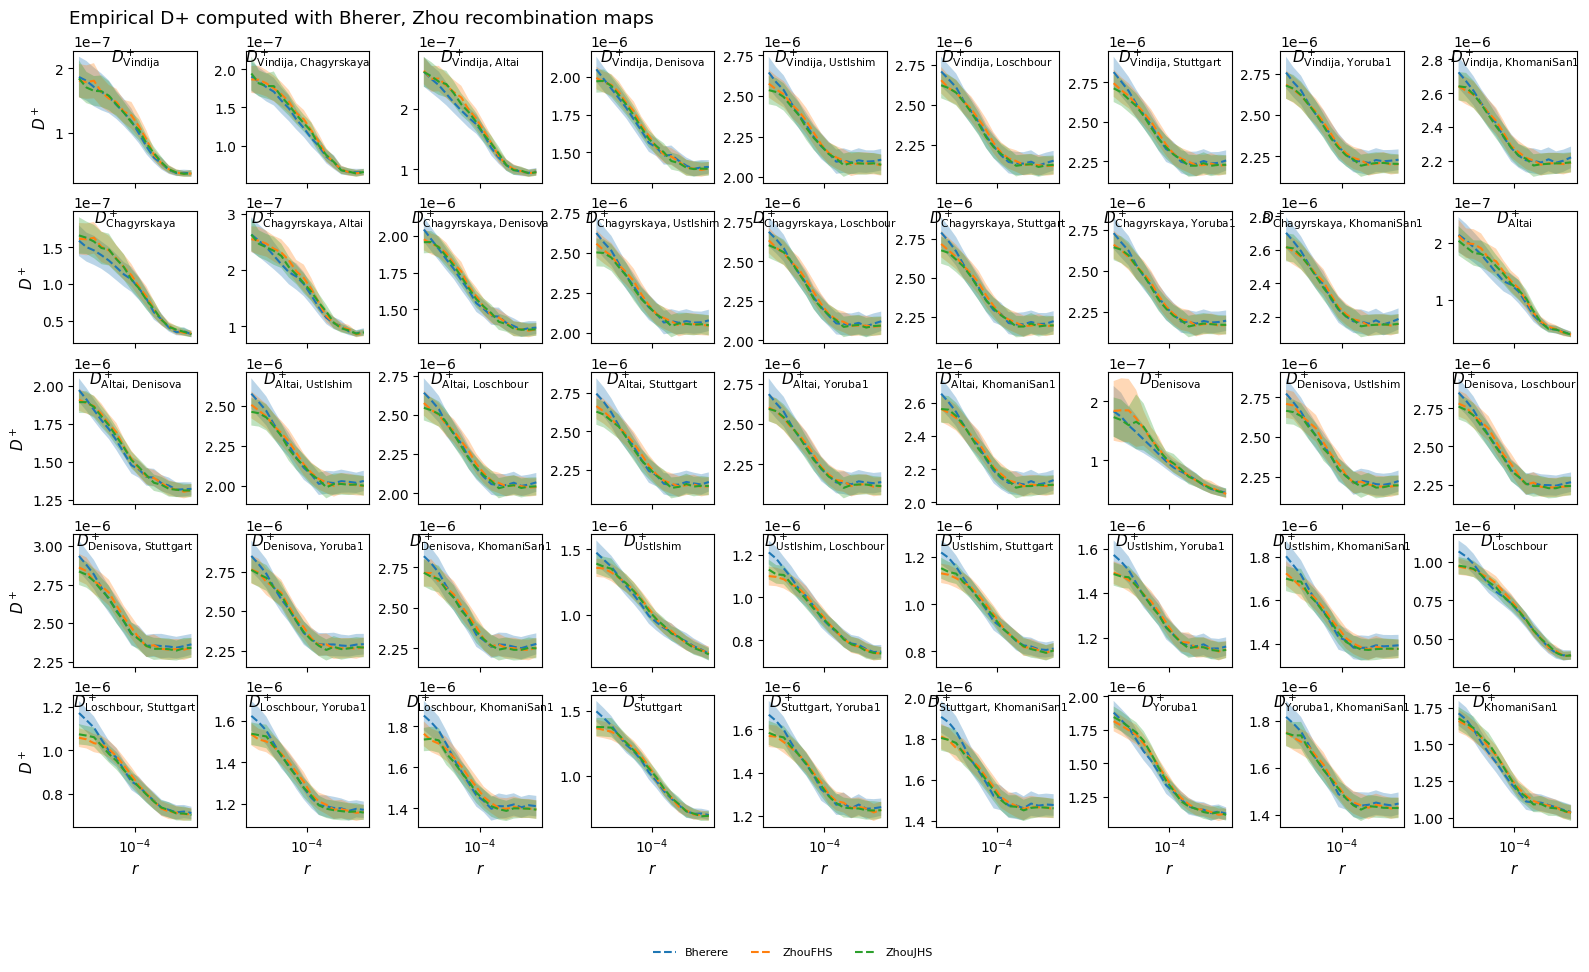

In [12]:
plot_pops = [
    "Vindija",
    "Chagyrskaya",
    "Altai",
    "Denisova",
    "UstIshim",
    "Loschbour",
    "Stuttgart",
    "Yoruba1",
    "KhomaniSan1"
]

Bherer_stats = dpluspy.bootstrapping.subset_stats(Bherer_stats, to_pops=plot_pops, return_dict=True)
ZhouFHS_stats = dpluspy.bootstrapping.subset_stats(ZhouFHS_stats, to_pops=plot_pops, return_dict=True)
ZhouJHS_stats = dpluspy.bootstrapping.subset_stats(ZhouJHS_stats, to_pops=plot_pops, return_dict=True)


dpluspy.plotting.plot_D_plus_curves(
    means=[Bherer_stats["means"], ZhouFHS_stats["means"], ZhouJHS_stats["means"]], 
    varcovs=[Bherer_stats["varcovs"], ZhouFHS_stats["varcovs"], ZhouJHS_stats["varcovs"]], 
    bins=Bherer_stats["bins"],
    pop_ids=plot_pops, 
    labels=["Bherere", "ZhouFHS", "ZhouJHS"], 
    out=f"figures/fig_subset_maps_summary.pdf",
    title=f"Empirical D+ computed with Bherer, Zhou recombination maps",
    show=False,
    cols=9,
    ax_size=1.75,
    colors=["tab:blue", "tab:orange", "tab:green"]
)